# Passo 1 - coleta de dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df= pd.read_csv('base_iris.csv');

# print(df.describe())
# print(df)
# print(f'linhas:{df.shape[0]} colunas: {df.shape[1]}')


# Limpeza Estrutural

linhas:145


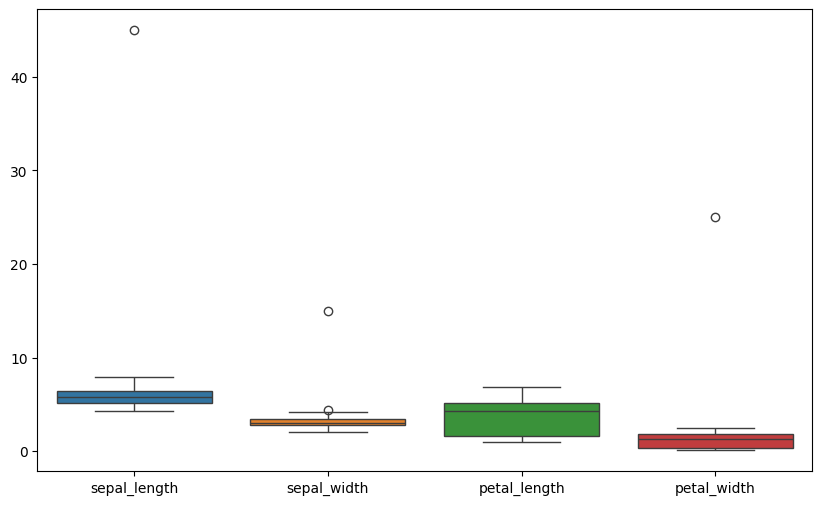

In [ ]:
from numpy import indices
# removendo coluna Unnamed
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])
# remover targerts nulos
df = df.dropna(subset=["target"])
# remover duplicadtas
df = df.drop_duplicates()
# remover valores negativos
colunas_analogicas=['petal_length','petal_width','sepal_length','sepal_width']
df=df.drop(df[(df[colunas_analogicas]<=0).any(axis=1)].index)



print(f'linhas:{df.shape[0]}')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.show()

# 3. Divisão

In [ ]:
x = df.drop(columns='target')
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42, stratify=y)

print(f'treino: {x_train.shape}')
print(f'teste: {x_test.shape}')

treino: (72, 4)
teste: (73, 4)


# passo 4: Pré Processamento

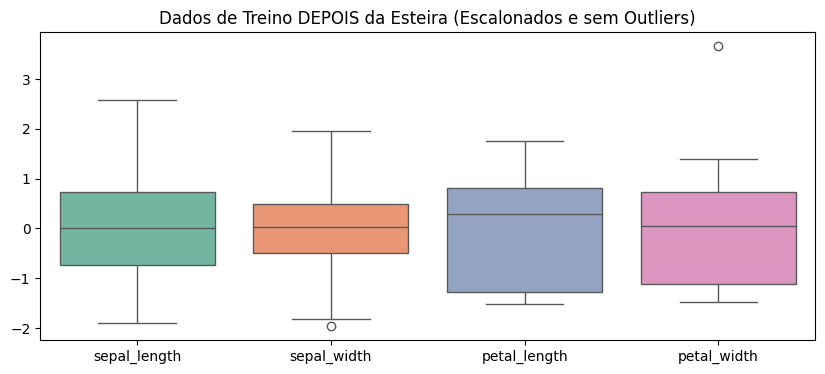

treino: (72, 4)
teste: (73, 4)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

class TratadorOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5):
        self.fator = fator
        self.limites = {}

    def fit(self, X, y=None):
        # A máquina "aprende" os limites APENAS olhando para os dados que entram aqui (Treino)
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.limites[col] = {
                'inferior': Q1 - self.fator * IQR,
                'superior': Q3 + self.fator * IQR
            }
        return self

    def transform(self, X):
        # A máquina aplica os limites aprendidos nos dados (Treino ou Teste)
        X_tratado = X.copy()
        for col, limites in self.limites.items():
            X_tratado[col] = X_tratado[col].clip(lower=limites['inferior'], upper=limites['superior'])
        return X_tratado


esteira_processamento = Pipeline(steps=[
    ('outliers', TratadorOutliersIQR()),         # 1º: Corta os outliers usando regras do treino
    ('imputer', SimpleImputer(strategy='mean')), # 2º: Preenche nulos com a média limpa
    ('scaler', StandardScaler())                 # 3º: Coloca na mesma escala
])
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
x_train_tratado = esteira_processamento.fit_transform(x_train)
x_test_tratado = esteira_processamento.transform(x_test)
codificador_alvo = LabelEncoder()
y_train_codificado = codificador_alvo.fit_transform(y_train)
y_test_codificado = codificador_alvo.fit_transform(y_test)
# (Opcional) Visão dos dados de treino após passar pela esteira
X_train_vis = pd.DataFrame(x_train_tratado, columns=cols_numericas)
plt.figure(figsize=(10, 4))
sns.boxplot(data=X_train_vis, palette="Set2")
plt.title("Dados de Treino DEPOIS da Esteira (Escalonados e sem Outliers)")
plt.show()

print(f'treino: {x_train_tratado.shape}')
print(f'teste: {x_test_tratado.shape}')

## escolha do modelo

In [ ]:
from sklearn.tree import DecisionTreeClassifier
## ecolha e cofr do modelo
modelo_arvore = DecisionTreeClassifier(random_state=42, max_depth=3)
##treino do modelo
modelo_arvore.fit(x_train_tratado, y_train_codificado)

DecisionTreeClassifier(max_depth=3, random_state=42)

## avaliação e validação

Acurácia: 0.9863013698630136
Acurácia Treino: 0.9722222222222222
Matriz de Confusão:
[[25  0  0]
 [ 0 24  1]
 [ 0  0 23]]


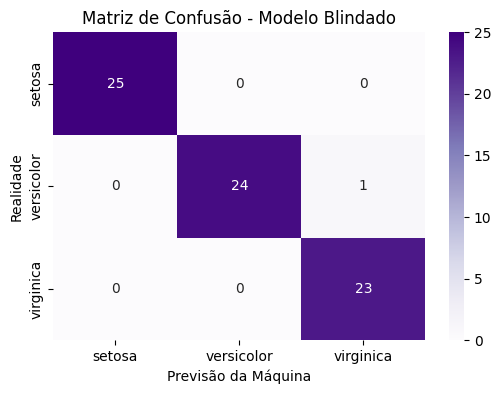

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Avaliação
predict_train = modelo_arvore.predict(x_train_tratado)
predict_test = modelo_arvore.predict(x_test_tratado)
#Validação
acuracia = accuracy_score(y_test_codificado, predict_test)
acuracia_treino = accuracy_score(y_train_codificado, predict_train)
print(f'Acurácia: {acuracia}')
print(f'Acurácia Treino: {acuracia_treino}')
#MATRIZ DE CONFUSÃO
matriz_confusao = confusion_matrix(y_test_codificado, predict_test)
print("Matriz de Confusão:")
print(matriz_confusao)
#plot dos resultados
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Purples',
            xticklabels=codificador_alvo.classes_,
            yticklabels=codificador_alvo.classes_)
plt.title('Matriz de Confusão - Modelo Blindado')
plt.xlabel('Previsão da Máquina')
plt.ylabel('Realidade')
plt.show()

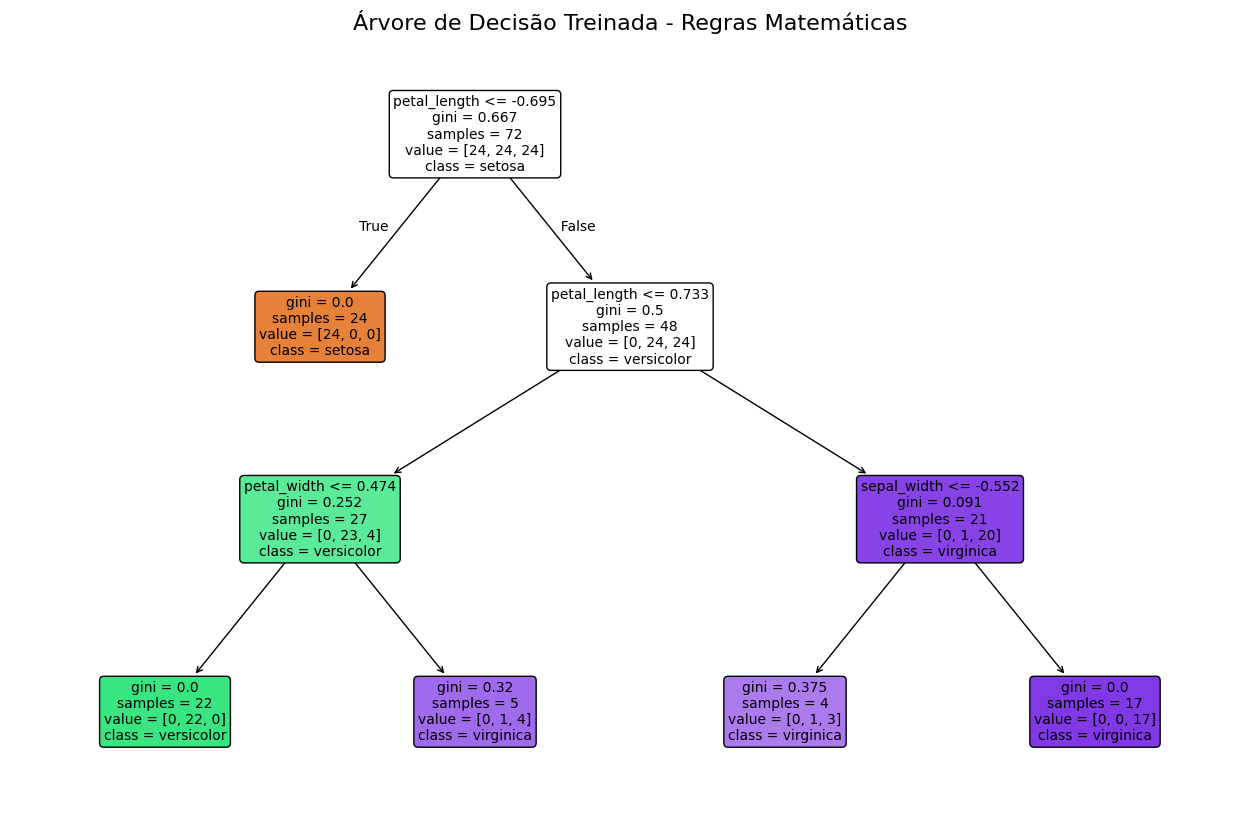

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Criar uma figura grande o suficiente para vermos os detalhes
plt.figure(figsize=(16, 10))

# Extrair os nomes das colunas (as nossas variáveis)
nomes_das_features = x.columns.tolist()

# Extrair os nomes das espécies (target) para o gráfico não mostrar apenas 0, 1 e 2
nomes_das_classes = codificador_alvo.classes_.tolist()

# Desenhar a árvore
plot_tree(modelo_arvore,
          feature_names=nomes_das_features,  # Mostra o nome da coluna usada na regra
          class_names=nomes_das_classes,     # Mostra o nome da espécie prevista
          filled=True,                       # Pinta as caixas com cores
          rounded=True,                      # Deixa os cantos das caixas arredondados
          fontsize=10)                       # Tamanho da letra

plt.title('Árvore de Decisão Treinada - Regras Matemáticas', fontsize=16)
plt.show()